<a href="https://colab.research.google.com/github/alyona-vishnoi/learning-RL/blob/main/cartpoledqn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Check out the environment

In [1]:
import gymnasium as gym

env = gym.make("CartPole-v1")

print("observation space:", env.observation_space)
# 4-dimensional array - cart's position, velocity, pole angle, and angular
print("action space:", env.action_space)
# push left or right

# reward = +1 for every single timestep the episode is still running, full stop.

# The pressure to balance is emergent, not built into the reward number:
# since the episode ends the moment the pole falls (or goes out of bounds),
# falling sooner just means fewer +1s accumulated.
# The only way to maximize total reward is to survive longer,
# and the only way to survive longer is to keep the pole roughly upright

# agent gets constant feedback instead of having to stumble into one sparse success
# so i'd expect it to train faster in comparision to frozenlake and be more "stable"
state, info = env.reset()
print("initial state:", state)

observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
action space: Discrete(2)
initial state: [-0.01897325  0.01604227 -0.0315787   0.03308782]


The episode terminates (terminated=True) if any of these happen:
- The pole angle exceeds about ±12 degrees from vertical — tips too far to recover.
- The cart position exceeds ±2.4 units from center — runs off the track.

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import deque
import torch
from torch import nn
import torch.nn.functional as F

In [3]:
# Define model
class DQN(nn.Module):
  def __init__(self, in_states, h1_nodes, out_actions):
      super().__init__()
      # define networks
      self.fc1 = nn.Linear(in_states, h1_nodes) # first fully connected layer 1
      self.out = nn.Linear(h1_nodes, out_actions) # output layer

  def forward(self,x):
    x = F.relu(self.fc1(x)) # apply relu activation
    x = self.out(x) # calculate output

    return x

In [4]:
class ReplayMemory():
  def __init__(self, maxlen):
    self.memory = deque([], maxlen)

  def append(self, transistion):
    self.memory.append(transistion)

  def sample(self, sample_size):
    return random.sample(self.memory, sample_size)

  def __len__(self):
    return len(self.memory)

In [5]:
class DQNAgent:
    def __init__(self, state_dim, action_dim, lr=1e-3, gamma=0.99,
                 epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995,
                 buffer_capacity=10000, batch_size=64, sync_freq=500):
        self.action_dim = action_dim
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.sync_freq = sync_freq
        self.step_count = 0

        self.policy_net = DQN(state_dim, 128, action_dim)
        self.target_net = DQN(state_dim, 128, action_dim)
        # initial sync
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval() # evaluation mode

        self.optimizer = torch.optim.Adam(self.policy_net.parameters(), lr=lr)
        self.buffer = ReplayMemory(buffer_capacity)

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        else:
            state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
            with torch.no_grad():
                q_values = self.policy_net(state_t)
            return torch.argmax(q_values).item()

    def store_transition(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def train_step(self):
        if len(self.buffer) < self.batch_size:
            return

        batch = self.buffer.sample(self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.tensor(states, dtype=torch.float32)
        actions = torch.tensor(actions, dtype=torch.int64).unsqueeze(1)
        rewards = torch.tensor(rewards, dtype=torch.float32)
        next_states = torch.tensor(next_states, dtype=torch.float32)
        dones = torch.tensor(dones, dtype=torch.float32)

        # pulls out only the Q-value for the action actually taken,
        # so 1 call instead of 32 for batch
        current_q = self.policy_net(states).gather(1, actions).squeeze(1)

        with torch.no_grad():
            max_next_q = self.target_net(next_states).max(1)[0]
            target_q = rewards + self.gamma * max_next_q * (1 - dones)

        # MSELoss over just the taken-action scalars
        loss = F.mse_loss(current_q, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.step_count += 1
        if self.step_count % self.sync_freq == 0:
            self.sync_target()

    def sync_target(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

The network's input layer needs exactly as many input neurons as there are numbers in that state vector, same logic as out_actions matching the number of possible actions.

In [7]:
# checking

In [8]:
state_dim = 4   # cart position, cart velocity, pole angle, pole angular velocity
action_dim = 2  # push left, push right

agent = DQNAgent(state_dim, action_dim)

dummy_state = env.reset()[0]   # just the state array, not the info dict
print("dummy state:", dummy_state)

action = agent.select_action(dummy_state)
print("action chosen:", action)
print("type:", type(action))

dummy state: [-0.03994589  0.0471673   0.04242266  0.0146195 ]
action chosen: 0
type: <class 'int'>


In [9]:
for i in range(5):
    agent.store_transition(dummy_state, 0, 1.0, dummy_state, False)

print(len(agent.buffer))  # should print 5

5


In [10]:
agent.train_step()  # should do nothing since buffer has only 5 < 64
print("no crash, good")

no crash, good


In [11]:
for i in range(100):
    agent.store_transition(dummy_state, random.randint(0,1), 1.0, dummy_state, False)

agent.train_step()  # this should now actually run the full Bellman update
print("ran a real training step")

ran a real training step


/tmp/ipykernel_1093/4228545184.py:42: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  states = torch.tensor(states, dtype=torch.float32)


Full training loop:

In [12]:
n_episodes = 1000

episode_rewards = []
epsilon_history = []

for episode in range(n_episodes):
    state, info = env.reset()
    terminated = truncated = False
    total_reward = 0

    while not (terminated or truncated):
        action = agent.select_action(state)
        next_state, reward, terminated, truncated, info = env.step(action)
        agent.store_transition(state, action, reward, next_state, terminated)
        agent.train_step()

        state = next_state
        total_reward += reward

    agent.decay_epsilon()
    episode_rewards.append(total_reward)
    epsilon_history.append(agent.epsilon)

    if (episode + 1) % 50 == 0:
        avg_reward = np.mean(episode_rewards[-50:])
        print(f"Episode {episode+1}, avg reward (last 50): {avg_reward:.1f}, epsilon: {agent.epsilon:.3f}")

print("Training done.")

Episode 50, avg reward (last 50): 22.2, epsilon: 0.778
Episode 100, avg reward (last 50): 37.0, epsilon: 0.606
Episode 150, avg reward (last 50): 102.5, epsilon: 0.471
Episode 200, avg reward (last 50): 176.8, epsilon: 0.367
Episode 250, avg reward (last 50): 245.1, epsilon: 0.286
Episode 300, avg reward (last 50): 291.5, epsilon: 0.222
Episode 350, avg reward (last 50): 214.5, epsilon: 0.173
Episode 400, avg reward (last 50): 348.2, epsilon: 0.135
Episode 450, avg reward (last 50): 234.6, epsilon: 0.105
Episode 500, avg reward (last 50): 242.7, epsilon: 0.082
Episode 550, avg reward (last 50): 423.2, epsilon: 0.063
Episode 600, avg reward (last 50): 485.5, epsilon: 0.049
Episode 650, avg reward (last 50): 348.5, epsilon: 0.038
Episode 700, avg reward (last 50): 256.8, epsilon: 0.030
Episode 750, avg reward (last 50): 401.3, epsilon: 0.023
Episode 800, avg reward (last 50): 235.1, epsilon: 0.018
Episode 850, avg reward (last 50): 334.6, epsilon: 0.014
Episode 900, avg reward (last 50):

plotting some metrics

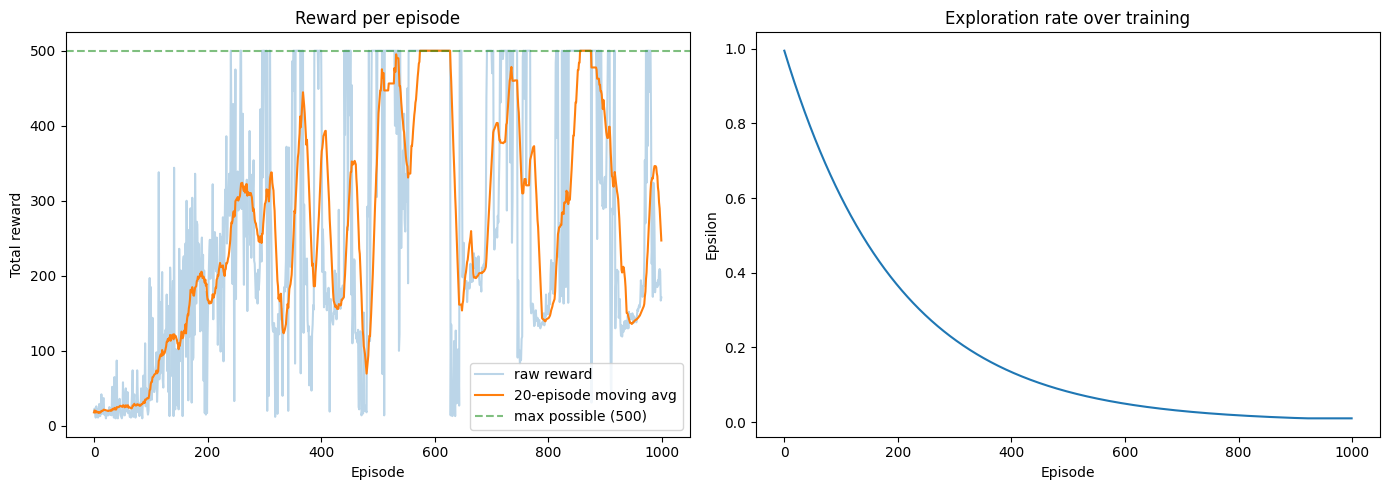

In [13]:
window = 20
moving_avg = [np.mean(episode_rewards[max(0,i-window):i+1]) for i in range(len(episode_rewards))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(episode_rewards, alpha=0.3, label='raw reward')
axes[0].plot(moving_avg, label=f'{window}-episode moving avg')
axes[0].axhline(500, color='green', linestyle='--', alpha=0.5, label='max possible (500)')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total reward')
axes[0].set_title('Reward per episode')
axes[0].legend()

axes[1].plot(epsilon_history)
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Epsilon')
axes[1].set_title('Exploration rate over training')

plt.tight_layout()
plt.show()